# AnalystLab Africa

## Machine Learning Internship Programme

### Week 1 — Machine Learning Problem Framing & Data Understanding

**Project:** Customer Churn Prediction
**Client:** ABC Communications Ltd

---

| | |
|---|---|
| **Intern Name** | Mulat Yazew Chekol |
| **Programme** | AnalystLab Africa — Machine Learning Internship Programme |
| **Week** | Week 1 — Machine Learning Problem Framing & Data Understanding |
| **Date** | August 9, 2026 |
| **Dataset** | Telco Customer Churn Dataset (IBM Sample Data, via Kaggle) |

---

<a id="exec-summary"></a>
## 1. Executive Summary

ABC Communications Ltd, a telecommunications provider, loses recurring revenue every time a subscriber cancels their service. Acquiring a new customer is widely understood to cost more than retaining an existing one, so the ability to identify **which customers are likely to leave before they leave** has direct commercial value. This notebook constitutes the Week 1 deliverable of the AnalystLab Africa Machine Learning Internship Programme and focuses exclusively on **problem framing and data understanding** — it deliberately stops short of building or evaluating a final predictive model.

**The business problem.** ABC Communications wants a way to flag existing customers who are at elevated risk of churning, early enough that a retention team can intervene (for example, with a targeted offer, a plan adjustment, or a support outreach).

**Why churn matters.** Churn directly erodes recurring revenue, increases customer-acquisition spend needed to replace lost subscribers, and reduces customer lifetime value. Even modest reductions in churn compound over time because retained customers continue generating revenue in future periods.

**What this notebook investigates.** Using the Telco Customer Churn dataset, the notebook inspects data structure, data quality (types, missing values, duplicates, inconsistent values), and the statistical relationships between customer attributes and churn. It then translates these observations into a formal machine learning problem definition and a concrete proposal for how modelling should proceed.

**Target variable.** The outcome to be predicted is `Churn` — whether a given customer left the company (`Yes`) or stayed (`No`).

**Type of ML problem.** This is a **supervised binary classification** problem: each customer record has a known historical outcome, and the goal is to learn a function that assigns new/existing customers a churn risk based on their attributes.

**What the analysis establishes.** The exploratory work below characterises the churn base rate, quantifies data quality issues (in particular the `TotalCharges` field), and identifies which customer attributes — such as contract type, tenure, payment method, and internet service — show the strongest observed association with churn. These findings directly inform which features are worth modelling and which preprocessing steps are required.

**Recommended next step.** Week 2 should proceed to building and validating baseline classification models (starting with an interpretable model such as Logistic Regression, followed by tree-based ensembles) using the preprocessing strategy and evaluation metrics proposed in this notebook. **No model has been trained or evaluated as part of this Week 1 submission.**

## Table of Contents

1. [Executive Summary](#exec-summary)
2. [Business Understanding](#business-understanding)
3. [Dataset Overview](#dataset-overview)
4. [Imports and Configuration](#imports-config)
5. [Data Loading](#data-loading)
6. [Dataset Inspection](#dataset-inspection)
7. [Data Quality Assessment](#data-quality)
8. [Data Cleaning Demonstration](#data-cleaning)
9. [Machine Learning Problem Framing](#ml-framing)
10. [Feature Classification](#feature-classification)
11. [Exploratory Data Analysis](#eda)
12. [Additional EDA](#additional-eda)
13. [Key Exploratory Findings](#key-findings)
14. [Preprocessing Strategy](#preprocessing-strategy)
15. [Model Planning](#model-planning)
16. [Evaluation Strategy](#evaluation-strategy)
17. [Machine Learning Proposal](#ml-proposal)
18. [Risks and Limitations](#risks-limitations)
19. [Final Conclusion](#conclusion)
20. [References](#references)
21. [Submission Checklist](#submission-checklist)

<a id="business-understanding"></a>
## 2. Business Understanding

### What is Machine Learning?

Machine Learning (ML) is a branch of artificial intelligence in which a system learns patterns directly from historical data, rather than following rules that a human has explicitly programmed. Instead of writing "if X then Y" logic by hand, an ML algorithm is shown many past examples — each with known inputs and a known outcome — and it learns a mathematical mapping between the two. That mapping can then be applied to new cases where the outcome is not yet known. In a business setting, ML is valuable precisely because it can uncover patterns in customer behaviour that would be difficult for a human analyst to specify manually.

### What is Predictive Analytics?

Predictive analytics is the practical application of statistical and machine learning techniques to historical data in order to estimate future or otherwise unknown outcomes. For ABC Communications, this means using records of customers who have *already* churned or stayed — along with their account details, service usage, and billing history — to estimate the likelihood that a *current* customer will churn. The underlying assumption is that customers who behave similarly to past churners (e.g. similar contract type, tenure, and billing patterns) carry a similar risk of churning.

### What is Customer Churn?

In telecommunications, **customer churn** refers to a subscriber terminating their relationship with the service provider — cancelling their phone, internet, or bundled service package. Churn is typically measured over a defined period (e.g. monthly or quarterly) as the proportion of the customer base that leaves. It is one of the most closely tracked metrics in subscription-based industries because it is a leading indicator of future revenue.

### Business Problem

> **Predict which existing customers are likely to churn so that the business can identify at-risk customers and take proactive retention actions.**

Framing the problem this way creates tangible business value:

- **Customer retention** — enables the retention team to prioritise outreach toward customers who are actually at risk, rather than contacting customers indiscriminately.
- **Reduced revenue loss** — retaining even a fraction of at-risk customers preserves recurring revenue that would otherwise be lost.
- **Better targeting of retention campaigns** — risk scores allow offers/discounts to be reserved for customers who need them, instead of being given broadly.
- **Improved customer lifetime value** — customers retained for longer periods generate more cumulative revenue.
- **More efficient allocation of customer-success resources** — support and retention staff can focus effort where it is most likely to change the outcome.

This notebook does not attempt to quantify these benefits in monetary terms, since doing so would require assumptions about intervention cost and effectiveness that are outside the scope of Week 1. The immediate goal is to establish that the problem is well-posed and that the available data supports it.

<a id="dataset-overview"></a>
## 3. Dataset Overview

This notebook uses the **Telco Customer Churn** dataset, a widely used public dataset (originally distributed by IBM) that is hosted on Kaggle at:
[https://www.kaggle.com/datasets/blastchar/telco-customer-churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

**What the dataset represents.** A snapshot of a fictional telecommunications company's customer base, including account information, subscribed services, billing details, and whether each customer had churned as of the snapshot date.

**What a row represents.** Each row is a single unique customer, identified by a `customerID`.

**What the columns represent, at a high level:**

| Category | Example columns |
|---|---|
| Identifier | `customerID` |
| Demographics | `gender`, `SeniorCitizen`, `Partner`, `Dependents` |
| Account tenure & billing | `tenure`, `Contract`, `PaperlessBilling`, `PaymentMethod`, `MonthlyCharges`, `TotalCharges` |
| Subscribed services | `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies` |
| Outcome / target | `Churn` |

**Why it is appropriate for this task.** The dataset contains a clearly defined, historically observed binary outcome (`Churn`) together with a rich set of plausible predictive attributes covering demographics, account characteristics, and subscribed services — exactly the structure required to frame and later solve a supervised churn-prediction problem.

**Target variable:** `Churn` — indicates whether the customer left the company (`Yes`) or remained (`No`) as of the snapshot.

<a id="imports-config"></a>
## 4. Imports and Configuration

Only the libraries required for data loading, inspection, and visualisation are imported. No modelling libraries are needed at this stage since Week 1 does not involve training a model.

In [31]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Display configuration
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Plot configuration — consistent, professional styling for every chart in this notebook
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["font.size"] = 10

# Fixed random seed used everywhere a random operation occurs, for reproducibility
RANDOM_STATE = 42

# Shared colour palette so churned/retained customers are always encoded consistently
CHURN_PALETTE = {"No": "#4C72B0", "Yes": "#C44E52"}

print("Libraries imported successfully.")
print(f"pandas version: {pd.__version__}")
print(f"seaborn version: {sns.__version__}")

Libraries imported successfully.
pandas version: 3.0.5
seaborn version: 0.13.2


<a id="data-loading"></a>
## 5. Data Loading

The cell below searches a list of likely local paths for the dataset before falling back to a documented failure message. This makes the notebook portable: it will find the file whether it is executed from the repository root or from inside a `notebooks/` folder, and whether the file uses the original Kaggle filename or a renamed variant.

**If the dataset is not found**, the cell raises a clear error explaining exactly where to obtain the file (Kaggle) and where to place it — the notebook does not fabricate or substitute synthetic data under any circumstance.

In [32]:
# Candidate filenames and locations for the Telco Customer Churn dataset.
# Both the original Kaggle filename and common renamed variants are checked,
# from both the repository root and a `notebooks/` working directory.
CANDIDATE_FILENAMES = [
    "WA_Fn-UseC_-Telco-Customer-Churn.csv",
    "Telco-Customer-Churn.csv",
    "telco-customer-churn.csv",
    "Telco_Customer_Churn.csv",
]
CANDIDATE_FOLDERS = [Path("."), Path(".."), Path("dataset"), Path("../dataset"),
                     Path("data"), Path("../data")]

candidate_paths = [folder / name for folder in CANDIDATE_FOLDERS for name in CANDIDATE_FILENAMES]
dataset_path = next((p for p in candidate_paths if p.exists()), None)

if dataset_path is None:
    searched = "\n".join(f"  - {p}" for p in candidate_paths)
    raise FileNotFoundError(
        "Could not locate the Telco Customer Churn dataset on the local filesystem.\n\n"
        "To proceed:\n"
        "  1. Download the dataset from Kaggle:\n"
        "     https://www.kaggle.com/datasets/blastchar/telco-customer-churn\n"
        "  2. Save the CSV file (commonly named 'WA_Fn-UseC_-Telco-Customer-Churn.csv')\n"
        "     into a 'dataset/' or 'data/' folder next to this notebook (or next to the\n"
        "     repository root).\n"
        "  3. Re-run this cell.\n\n"
        f"Locations searched:\n{searched}\n\n"
        "This notebook intentionally does not fabricate substitute data — all analysis\n"
        "below depends on the real dataset being present."
    )

df = pd.read_csv(dataset_path)
df_raw = df.copy()  # untouched copy of the originally loaded data, preserved for reference

print(f"Dataset successfully loaded from: {dataset_path.resolve()}")
print(f"Rows:    {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset successfully loaded from: /Users/mulatyazewchekol/Documents/My_Projects/ANALYSTLAB_AFRICA_INTERNSHIP/dataset/Telco-Customer-Churn.csv
Rows:    7,043
Columns: 21


In [33]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<a id="dataset-inspection"></a>
## 6. Dataset Inspection

### 6.1 Dataset Shape

In [34]:
n_rows, n_cols = df.shape
print(f"The dataset contains {n_rows:,} rows (customers) and {n_cols} columns (attributes).")

The dataset contains 7,043 rows (customers) and 21 columns (attributes).


Each row corresponds to one customer, so the dataset covers several thousand individual customer records — a reasonable sample size for identifying statistical patterns in churn behaviour.

### 6.2 Random Sample

A random sample (fixed seed for reproducibility) is inspected to confirm the first-rows view is representative and not an artifact of row ordering.

In [35]:
df.sample(5, random_state=RANDOM_STATE)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
185,1024-GUALD,Female,0,Yes,No,1,No,No phone service,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,24.80,24.8,Yes
2715,0484-JPBRU,Male,0,No,No,41,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),25.25,996.45,No
3825,3620-EHIMZ,Female,0,Yes,Yes,52,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.35,1031.7,No
1807,6910-HADCM,Female,0,No,No,1,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,No,Electronic check,76.35,76.35,Yes
132,8587-XYZSF,Male,0,No,No,67,Yes,No,DSL,No,No,No,Yes,No,No,Two year,No,Bank transfer (automatic),50.55,3260.1,No


### 6.3 Data Types and Column Names

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

Most columns are stored as text (`object`) because they represent categorical service or account attributes (e.g. `Yes`/`No` flags, contract types). `SeniorCitizen` is numeric (0/1) despite being conceptually binary-categorical. `tenure` and `MonthlyCharges` are numeric as expected. Notably, **`TotalCharges` is stored as `object` (text) rather than a numeric type** — this is investigated in the Data Quality Assessment section below, since it should logically be numeric.

### 6.4 Numerical Summary

In [37]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Observations from the numeric summary:

- `tenure` ranges from 0 to the maximum observed tenure in months, with the distribution spanning new customers through to long-tenured ones.
- `MonthlyCharges` shows a wide spread, consistent with customers subscribing to different combinations of services (e.g. phone only vs. phone + internet + streaming add-ons).
- `SeniorCitizen` is a 0/1 flag, so its "mean" is directly interpretable as the proportion of customers who are senior citizens, not a meaningful magnitude.
- `TotalCharges` does not appear here because it is currently stored as text, not a number — addressed in the next section.

### 6.5 Categorical Summary

In [38]:
df.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


The categorical summary confirms that most service-related columns take a small number of discrete values (e.g. `Yes`, `No`, `No internet service`), which is consistent with them being suitable candidates for one-hot encoding. `customerID` has as many unique values as there are rows, confirming it functions purely as a row identifier rather than a descriptive attribute.

<a id="data-quality"></a>
## 7. Data Quality Assessment

### 7.1 Missing Values

In [39]:
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df) * 100).round(2)

missing_table = (
    pd.DataFrame({"Missing Count": missing_count, "Missing %": missing_pct})
    .sort_values("Missing Count", ascending=False)
)

missing_table

,Missing Count,Missing %
customerID,0,0.0
DeviceProtection,0,0.0
TotalCharges,0,0.0
MonthlyCharges,0,0.0
PaymentMethod,0,0.0
PaperlessBilling,0,0.0
Contract,0,0.0
StreamingMovies,0,0.0
StreamingTV,0,0.0
TechSupport,0,0.0


In [40]:
total_missing = int(missing_count.sum())
if total_missing == 0:
    print("pandas' isnull() reports 0 missing (NaN) values across all columns.")
else:
    print(f"pandas' isnull() reports {total_missing} missing (NaN) values in total.")
print("This check alone can be misleading — see the TotalCharges inspection below.")

pandas' isnull() reports 0 missing (NaN) values across all columns.
This check alone can be misleading — see the TotalCharges inspection below.


A standard `isnull()` check reports no missing values — but this can be misleading when missing data has been encoded as **blank/whitespace strings** rather than true `NaN`. `TotalCharges` is stored as text (see Section 8.3), so it is explicitly checked for blank entries below rather than assuming it is clean.

In [41]:
is_blank = df["TotalCharges"].astype(str).str.strip().eq("")
n_blank = int(is_blank.sum())

print(f"Blank/whitespace-only entries in 'TotalCharges': {n_blank} "
      f"({n_blank / len(df) * 100:.2f}% of rows)")

df.loc[is_blank, ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

Blank/whitespace-only entries in 'TotalCharges': 11 (0.16% of rows)


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [42]:
tenure_values_for_blanks = df.loc[is_blank, "tenure"].unique()
print(f"Distinct 'tenure' values among rows with blank TotalCharges: {tenure_values_for_blanks}")

Distinct 'tenure' values among rows with blank TotalCharges: [0]


The rows with a blank `TotalCharges` all share `tenure = 0`, i.e. they are customers who joined so recently that no billing cycle has completed yet. This is a data-quality issue that **numeric type coercion alone will not fix silently** — it must be handled deliberately (see Data Cleaning Demonstration below).

### 7.2 Duplicate Rows

In [43]:
n_full_duplicates = df.duplicated().sum()
n_id_duplicates = df["customerID"].duplicated().sum()

print(f"Fully duplicated rows (all columns identical): {n_full_duplicates} "
      f"({n_full_duplicates / len(df) * 100:.2f}%)")
print(f"Duplicate customerID values: {n_id_duplicates} "
      f"({n_id_duplicates / len(df) * 100:.2f}%)")

Fully duplicated rows (all columns identical): 0 (0.00%)
Duplicate customerID values: 0 (0.00%)


The result above is computed directly from the loaded data — see the printed counts. If both counts are zero, each row represents a distinct customer with no exact-duplicate records, which is the expected state for a clean, one-row-per-customer extract.

### 7.3 Unique Values in Key Categorical Variables

In [44]:
categorical_cols = df.select_dtypes(include="object").columns.drop("customerID")

for col in categorical_cols:
    values = df[col].unique()
    print(f"{col} ({len(values)} unique): {list(values)}")

gender (2 unique): ['Female', 'Male']
Partner (2 unique): ['Yes', 'No']
Dependents (2 unique): ['No', 'Yes']
PhoneService (2 unique): ['No', 'Yes']
MultipleLines (3 unique): ['No phone service', 'No', 'Yes']
InternetService (3 unique): ['DSL', 'Fiber optic', 'No']
OnlineSecurity (3 unique): ['No', 'Yes', 'No internet service']
OnlineBackup (3 unique): ['Yes', 'No', 'No internet service']
DeviceProtection (3 unique): ['No', 'Yes', 'No internet service']
TechSupport (3 unique): ['No', 'Yes', 'No internet service']
StreamingTV (3 unique): ['No', 'Yes', 'No internet service']
StreamingMovies (3 unique): ['No', 'Yes', 'No internet service']
Contract (3 unique): ['Month-to-month', 'One year', 'Two year']
PaperlessBilling (2 unique): ['Yes', 'No']
PaymentMethod (4 unique): ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']
TotalCharges (6531 unique): ['29.85', '1889.5', '108.15', '1840.75', '151.65', '820.5', '1949.4', '301.9', '3046.05', '3487.95', '

Every categorical column takes a small, well-defined set of values (mostly `Yes`/`No`, plus a handful of service-tier labels such as `No internet service`). No unexpected free-text categories or inconsistent capitalisation/spelling variants (e.g. `"yes"` vs `"Yes"`) are present.

### 7.4 Invalid / Inconsistent Values

The checks below look for blank strings hidden inside otherwise-categorical columns, and for numeric values that would be logically impossible (e.g. negative charges or negative tenure).

In [45]:
print("Blank/whitespace-only string checks (excluding customerID):")
any_blanks_found = False
for col in df.select_dtypes(include="object").columns:
    n_blank_col = df[col].astype(str).str.strip().eq("").sum()
    if n_blank_col > 0:
        print(f"  {col}: {n_blank_col} blank entries")
        any_blanks_found = True
if not any_blanks_found:
    print("  None found in any text column.")

print()
print("Numeric range sanity checks:")
print(f"  tenure          -> min {df['tenure'].min()}, max {df['tenure'].max()}")
print(f"  MonthlyCharges  -> min {df['MonthlyCharges'].min()}, max {df['MonthlyCharges'].max()}")
n_negative_tenure = (df["tenure"] < 0).sum()
n_negative_charges = (df["MonthlyCharges"] < 0).sum()
print(f"  Negative tenure values: {n_negative_tenure}")
print(f"  Negative MonthlyCharges values: {n_negative_charges}")

Blank/whitespace-only string checks (excluding customerID):
  TotalCharges: 11 blank entries

Numeric range sanity checks:
  tenure          -> min 0, max 72
  MonthlyCharges  -> min 18.25, max 118.75
  Negative tenure values: 0
  Negative MonthlyCharges values: 0


Aside from the blank `TotalCharges` entries already identified (which are not caught by the "blank string" scan above because that scan only flagged them at the point of conversion), the dataset shows no negative charges, no negative tenure, and no stray blank strings in the other categorical fields. The single, well-understood data quality issue in this dataset is the text-typed `TotalCharges` column with 11 blank entries corresponding to zero-tenure customers.

<a id="data-cleaning"></a>
## 8. Data Cleaning Demonstration

Week 1 focuses on demonstrating that preprocessing needs are understood, not on building a production pipeline. The single concrete cleaning step performed here is converting `TotalCharges` to a numeric type, on a **copy** of the data so the originally loaded `df` remains untouched.

In [46]:
df_clean = df.copy()
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")

n_new_missing = df_clean["TotalCharges"].isnull().sum()
print(f"Missing values in 'TotalCharges' after numeric coercion: {n_new_missing}")
print(f"Missing values in 'TotalCharges' before coercion (blank strings): {n_blank}")

Missing values in 'TotalCharges' after numeric coercion: 11
Missing values in 'TotalCharges' before coercion (blank strings): 11


In [47]:
df_clean.loc[df_clean["TotalCharges"].isnull(), ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


`pd.to_numeric(..., errors="coerce")` converts the blank strings into proper `NaN` values, which is why the missing count only appears *after* conversion — the raw text column never registered as missing under a simple `isnull()` check. This is exactly why the earlier inspection could not assume `TotalCharges` was clean without explicitly checking it.

**Why this happens:** these customers have `tenure = 0`, meaning they had not yet been billed at the time the dataset was captured, so no total-charges figure existed to record.

**What should be done in future model development:**
- These rows should **not** be silently dropped without justification, since they are legitimate customers (not data-entry errors).
- A sensible imputation is `TotalCharges = 0` (consistent with zero completed billing cycles) or `TotalCharges ≈ MonthlyCharges × tenure`, decided during the modelling phase.
- Any imputation strategy must be fit using only the training split to avoid leaking information from the test set.

**Other preprocessing considerations identified for the modelling phase (not performed here):**
- **Encoding categorical variables** — binary Yes/No fields can be label-encoded (0/1); multi-class fields (e.g. `Contract`, `PaymentMethod`, `InternetService`) require one-hot encoding.
- **Scaling numerical variables** — `tenure`, `MonthlyCharges`, and `TotalCharges` are on different scales and should be standardised for scale-sensitive algorithms such as Logistic Regression.
- **Handling missing values** — the `TotalCharges` imputation strategy above must be finalised and applied consistently.
- **Avoiding data leakage** — any imputer, scaler, or encoder must be *fit* only on the training partition and then *applied* (transformed) to the test partition, never the reverse.
- **Train/test splitting before fitting transformations** — the split must happen first, and all preprocessing objects fit afterward on the training data only, typically implemented with a scikit-learn `Pipeline`/`ColumnTransformer`.

No cleaned-data statistics beyond the counts computed above are asserted — `df_clean` is used only for the correlation heatmap in the EDA section, where a numeric `TotalCharges` is required.

<a id="ml-framing"></a>
## 9. Machine Learning Problem Framing

This section directly answers the six core problem-framing questions. It is the most heavily weighted part of the assignment and is intended to be read as a standalone problem definition.

### Question 1 — What business problem should the model solve?

The model should estimate, for each existing customer, the probability that they will churn within the relevant forward-looking period. This score allows ABC Communications to **rank customers by risk** and route the highest-risk, highest-value customers to proactive retention workflows (outreach, incentives, plan adjustments) before they cancel, rather than reacting only after a customer has already left.

### Question 2 — What is the target variable?

The target variable is **`Churn`**, a binary label recorded as `Yes` (the customer left) or `No` (the customer stayed). It is the correct target because it is the exact outcome the business wants to anticipate — every other column in the dataset describes a customer *characteristic*, while `Churn` describes the *outcome* those characteristics are hypothesised to predict.

### Question 3 — Which input features should be used?

Most of the remaining columns are plausible predictors and fall into a few natural groups:

- **Account / contract:** `tenure`, `Contract`, `PaperlessBilling`, `PaymentMethod`, `MonthlyCharges`, `TotalCharges`
- **Demographics:** `SeniorCitizen`, `Partner`, `Dependents`, `gender`
- **Core service:** `PhoneService`, `MultipleLines`, `InternetService`
- **Value-added / support services:** `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`

Not every feature should be assumed useful by default:

- **`customerID` must be excluded.** It is a unique row identifier with one distinct value per customer (confirmed in Section 8.5) and carries no generalisable information — including it would either be ignored by a model or, worse, allow overfitting to arbitrary ID patterns that will not repeat for future customers.
- **`gender`** shows no strong a priori business rationale for affecting churn and should be evaluated empirically rather than assumed predictive; it is kept as a candidate feature but flagged for feature-importance review during modelling.
- Highly correlated numeric pairs (e.g. `tenure` and `TotalCharges`, explored in Section 11's correlation heatmap) may warrant dimensionality reduction or careful feature selection later, since redundant features add noise without adding information for some algorithms.

The final feature set should be confirmed empirically (e.g. via feature importance or coefficient inspection) during Week 2 modelling, not decided purely on intuition.

### Question 4 — Classification or regression?

**This is a binary classification problem.** The target `Churn` takes exactly two mutually exclusive categorical outcomes (`Yes` / `No`) rather than a continuous numeric quantity, which is the defining characteristic of a classification task (as opposed to regression, which predicts continuous values such as revenue or price).

### Question 5 — Which evaluation metrics are appropriate?

| Metric | What it measures | Relevance here |
|---|---|---|
| **Accuracy** | Overall proportion of correct predictions | Easy to interpret but can be misleading under class imbalance (see below) |
| **Precision** | Of customers predicted to churn, how many actually did | Matters if retention offers are costly and should not be wasted on customers who would have stayed anyway |
| **Recall** | Of customers who actually churned, how many were correctly identified | **Especially important** — a customer who is missed by the model receives no retention intervention and is lost |
| **F1-score** | Harmonic mean of precision and recall | Useful single-number summary when both false positives and false negatives carry a cost |
| **ROC-AUC** | Model's ability to rank churners above non-churners across all thresholds | Threshold-independent view of overall discriminative power |
| **Confusion Matrix** | Full breakdown of true/false positives and negatives | Makes the trade-off between missed churners and false alarms explicit for business stakeholders |

**Why accuracy alone is insufficient:** the exploratory analysis below shows that churners are a minority of the customer base. A model that simply predicted "No churn" for every customer would still score a high accuracy while providing zero business value, since it would never identify a single at-risk customer. **Recall deserves particular attention** because a false negative (a churner the model misses) represents a lost customer and lost revenue that the business had a chance to prevent, whereas a false positive (a flagged customer who was not actually going to churn) typically only costs the price of an unnecessary — but not harmful — retention offer.

### Question 6 — Which algorithms are suitable?

| Algorithm | Strengths | Weaknesses |
|---|---|---|
| **Logistic Regression** | Highly interpretable coefficients; fast to train; strong, well-understood baseline; outputs calibrated probabilities | Assumes a roughly linear relationship between features and log-odds of churn; may underfit complex interactions |
| **Decision Tree** | Captures non-linear relationships and feature interactions; easy to visualise and explain to non-technical stakeholders | Prone to overfitting if not depth-limited; unstable to small data changes |
| **Random Forest** | Ensemble of trees reduces overfitting relative to a single tree; typically strong out-of-the-box accuracy; provides feature importances | Less directly interpretable than a single tree or logistic regression; slower to train and score than simpler models |

**Optional future alternatives** (worth benchmarking once baselines are established): **Gradient Boosting**, and modern boosted-tree libraries such as **XGBoost**, **LightGBM**, or **CatBoost** — these often achieve the strongest raw predictive performance on tabular data of this kind, at the cost of additional tuning complexity and reduced interpretability relative to logistic regression.

No models are trained in this notebook; algorithm selection here is a **plan**, to be executed and validated in Week 2.

<a id="feature-classification"></a>
## 10. Feature Classification

Each column is programmatically classified below by role — Identifier, Target, Numerical, Binary categorical, or Multi-class categorical — using the cleaned typing established in Section 10 (so that `TotalCharges` is correctly recognised as numeric).

In [48]:
def classify_feature(column: str) -> str:
    if column == "customerID":
        return "Identifier (non-predictive)"
    if column == "Churn":
        return "Target variable"
    is_numeric_dtype = pd.api.types.is_numeric_dtype(df_clean[column])
    n_unique = df_clean[column].nunique()
    if is_numeric_dtype and n_unique > 2:
        return "Numerical"
    if n_unique == 2:
        return "Binary categorical"
    return "Multi-class categorical"


feature_classification = pd.DataFrame({
    "Feature": df_clean.columns,
    "Data Type": [str(df_clean[c].dtype) for c in df_clean.columns],
    "Unique Values": [df_clean[c].nunique() for c in df_clean.columns],
    "Role": [classify_feature(c) for c in df_clean.columns],
})

feature_classification

,Feature,Data Type,Unique Values,Role
0,customerID,str,7043,Identifier (non-predictive)
1,gender,str,2,Binary categorical
2,SeniorCitizen,int64,2,Binary categorical
3,Partner,str,2,Binary categorical
4,Dependents,str,2,Binary categorical
5,tenure,int64,73,Numerical
6,PhoneService,str,2,Binary categorical
7,MultipleLines,str,3,Multi-class categorical
8,InternetService,str,3,Multi-class categorical
9,OnlineSecurity,str,3,Multi-class categorical


Key points arising from this classification:

- **`customerID`** is correctly isolated as a non-predictive identifier and must never be passed to a model as a feature.
- **`SeniorCitizen`** is stored as an integer (0/1) but is conceptually a **binary categorical** flag, not a continuous quantity — its classification above reflects that.
- **`tenure`, `MonthlyCharges`, `TotalCharges`** are genuine numerical features and are candidates for scaling.
- The **service and account columns** (`Contract`, `PaymentMethod`, `InternetService`, `OnlineSecurity`, etc.) are categorical, split between binary (`Yes`/`No`) and multi-class (e.g. three contract types) — this distinction determines whether simple binary mapping or one-hot encoding is appropriate for each.
- **`Churn`** is explicitly separated out as the **target variable** and is excluded from the predictor set in all downstream feature discussion.

<a id="eda"></a>
## 11. Exploratory Data Analysis

Every chart in this section is built to answer a specific business question rather than shown for its own sake. Two small helper functions are defined once and reused across the churn-rate bar charts to avoid repeating plotting code.

In [49]:
def compute_churn_rate(data: pd.DataFrame, column: str) -> pd.Series:
    '''Return churn rate (%) per category of `column`, sorted highest to lowest.'''
    rate = data.groupby(column)["Churn"].apply(lambda s: (s == "Yes").mean() * 100)
    return rate.sort_values(ascending=False)


def plot_churn_rate_bar(rate_series: pd.Series, title: str, xlabel: str, figsize=(8, 5)):
    '''Bar chart of churn rate (%) by category, with value labels above each bar.'''
    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.bar(rate_series.index.astype(str), rate_series.values,
                   color="#C44E52", edgecolor="black", linewidth=0.6)
    for bar, value in zip(bars, rate_series.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
                f"{value:.1f}%", ha="center", va="bottom", fontsize=9)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Churn Rate (%)")
    ax.set_ylim(0, rate_series.values.max() * 1.2)
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.show()

### Bar Chart 1 — Overall Churn Distribution

**Business question:** How many customers in the current base have churned, and what proportion does that represent?

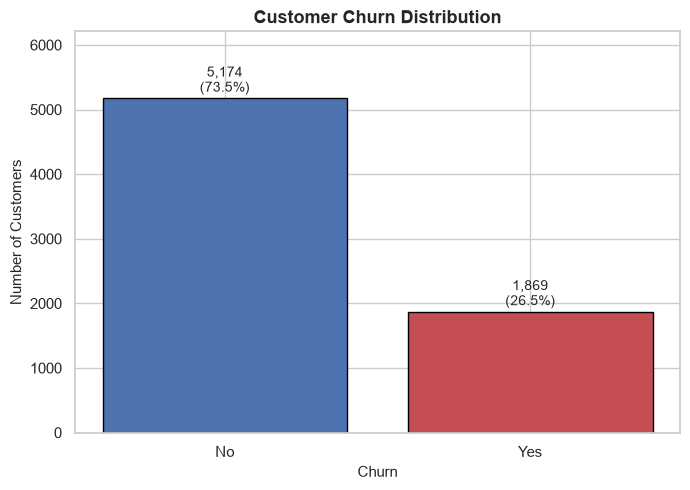

Churned customers: 1,869 (26.5%)
Retained customers: 5,174 (73.5%)


In [50]:
churn_counts = df["Churn"].value_counts()

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(churn_counts.index, churn_counts.values,
              color=[CHURN_PALETTE[c] for c in churn_counts.index], edgecolor="black")
for bar, value in zip(bars, churn_counts.values):
    pct = value / len(df) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 40,
            f"{value:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=10)

ax.set_title("Customer Churn Distribution")
ax.set_xlabel("Churn")
ax.set_ylabel("Number of Customers")
ax.set_ylim(0, churn_counts.values.max() * 1.2)
plt.tight_layout()
plt.show()

print(f"Churned customers: {churn_counts.get('Yes', 0):,} "
      f"({churn_counts.get('Yes', 0) / len(df) * 100:.1f}%)")
print(f"Retained customers: {churn_counts.get('No', 0):,} "
      f"({churn_counts.get('No', 0) / len(df) * 100:.1f}%)")

**Interpretation.** Churned customers are a clear minority of the overall base (see the printed percentages above). This confirms a **class-imbalanced classification problem**, which is precisely why accuracy alone was flagged as an insufficient evaluation metric in Section 11 — a naive model that always predicts "No churn" would score a high accuracy while identifying zero at-risk customers.

### Bar Chart 2 — Churn Rate by Contract Type

**Business question:** Does the type of contract a customer is on relate to their likelihood of churning?

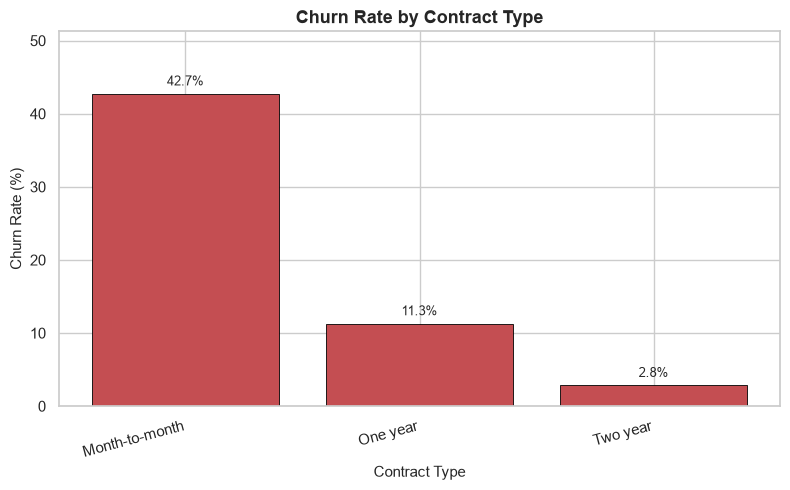

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64

In [51]:
rate_by_contract = compute_churn_rate(df, "Contract")
plot_churn_rate_bar(rate_by_contract, "Churn Rate by Contract Type", "Contract Type")
rate_by_contract

**Interpretation.** Churn rate is not evenly spread across contract types — see the exact percentages printed above. Month-to-month contracts, which carry no cancellation commitment, show a markedly higher churn rate than one-year or two-year contracts. **So what does this mean for the business?** Contract length is a strong candidate predictive feature, and the retention team may also consider incentivising longer-term contracts as a lever, independent of any predictive model.

### Bar Chart 3 — Churn Rate by Payment Method

**Business question:** Is churn associated with how customers pay their bill?

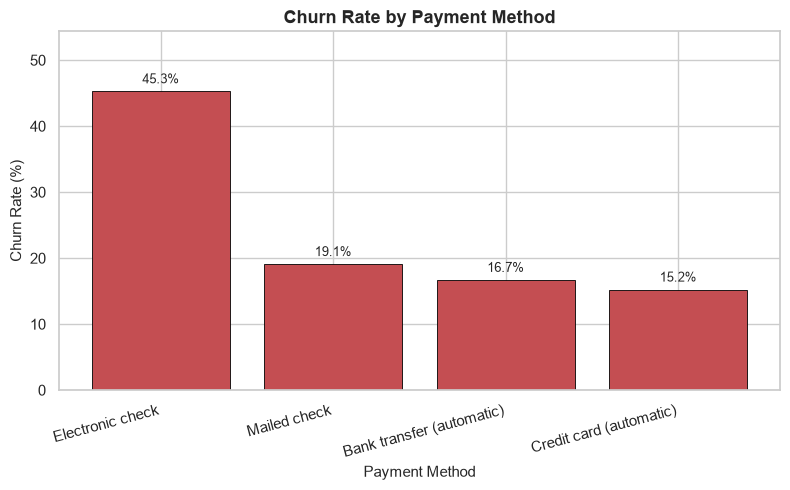

PaymentMethod
Electronic check             45.285412
Mailed check                 19.106700
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: Churn, dtype: float64

In [52]:
rate_by_payment = compute_churn_rate(df, "PaymentMethod")
plot_churn_rate_bar(rate_by_payment, "Churn Rate by Payment Method", "Payment Method")
rate_by_payment

**Interpretation.** Payment method shows a wide spread in observed churn rate (see values above), with manual/electronic payment options associated with higher churn than automatic payment methods (bank transfer or credit card). **So what does this mean for the business?** Customers on manual payment methods may be less "locked in" to the relationship, or may be more price-sensitive; payment method is a useful, low-cost-to-collect predictive feature, and may also suggest a retention lever (encouraging enrolment in automatic payments).

### Histogram 1 — Distribution of Tenure

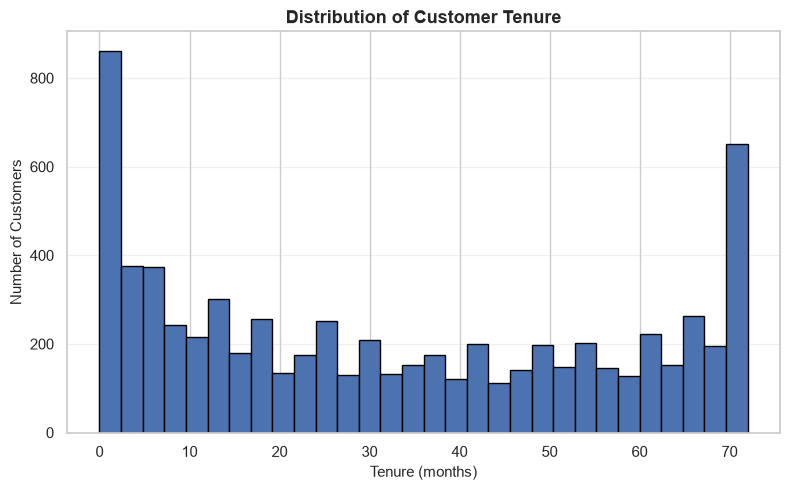

count    7043.0
mean       32.4
std        24.6
min         0.0
25%         9.0
50%        29.0
75%        55.0
max        72.0
Name: tenure, dtype: float64


In [53]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["tenure"], bins=30, color="#4C72B0", edgecolor="black")
ax.set_title("Distribution of Customer Tenure")
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Number of Customers")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(df["tenure"].describe().round(1))

**Interpretation.** The tenure distribution is not a simple bell curve — the printed summary statistics and histogram together show a large concentration of very-new customers (low tenure) alongside a substantial group of long-tenured customers near the maximum observed tenure, with relatively fewer customers in between. This U-shape is common in subscription businesses: a steady stream of new sign-ups, and a "survivor" population that has stayed for a long time, with a moderate attrition rate steadily thinning the middle.

### Histogram 2 — Distribution of Monthly Charges

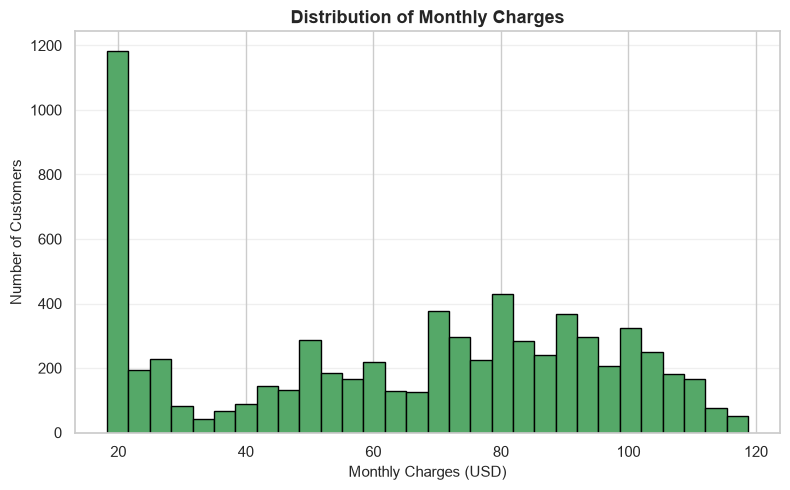

count    7043.0
mean       64.8
std        30.1
min        18.2
25%        35.5
50%        70.4
75%        89.8
max       118.8
Name: MonthlyCharges, dtype: float64


In [54]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["MonthlyCharges"], bins=30, color="#55A868", edgecolor="black")
ax.set_title("Distribution of Monthly Charges")
ax.set_xlabel("Monthly Charges (USD)")
ax.set_ylabel("Number of Customers")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(df["MonthlyCharges"].describe().round(1))

**Interpretation.** Monthly charges are spread across a wide range (see the printed summary), with a visible concentration of customers at the low end — consistent with customers who subscribe only to basic phone service — and a broader, flatter spread at higher charge levels associated with bundled internet and add-on services. **So what does this mean for the business?** `MonthlyCharges` captures how much service a customer has subscribed to, which is a reasonable proxy for both revenue-at-risk and service complexity.

### Correlation Heatmap — Numerical Variables

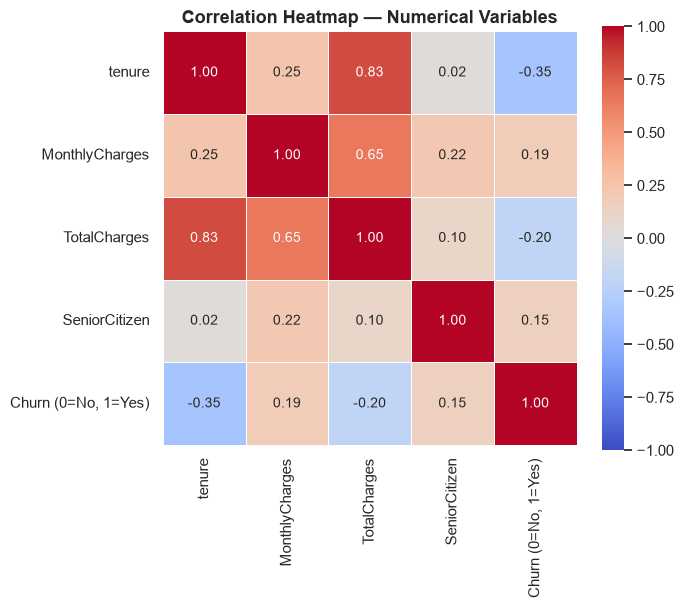

,tenure,MonthlyCharges,TotalCharges,SeniorCitizen,"Churn (0=No, 1=Yes)"
tenure,1.000000,0.247900,0.825880,0.016567,-0.352229
MonthlyCharges,0.247900,1.000000,0.651065,0.220173,0.193356
TotalCharges,0.825880,0.651065,1.000000,0.102411,-0.199484
SeniorCitizen,0.016567,0.220173,0.102411,1.000000,0.150889
"Churn (0=No, 1=Yes)",-0.352229,0.193356,-0.199484,0.150889,1.000000


In [55]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
corr_data = df_clean[numeric_cols].copy()
corr_data["Churn (0=No, 1=Yes)"] = (df_clean["Churn"] == "Yes").astype(int)

correlation_matrix = corr_data.corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation Heatmap — Numerical Variables")
plt.tight_layout()
plt.show()

correlation_matrix

**Interpretation.** `Churn` is numerically encoded here (0 = No, 1 = Yes) *purely to include it in this correlation view* — it remains a categorical target everywhere else in the notebook, and this encoding does not imply it should be treated as a continuous variable during modelling.

Reading the matrix above:

- **Strong positive relationship:** `tenure` and `TotalCharges` are strongly positively correlated, which follows arithmetically — customers accumulate total charges the longer they stay subscribed.
- **Moderate positive relationship:** `MonthlyCharges` and `TotalCharges` are moderately positively correlated, since higher monthly bills accumulate to a higher total over time (moderated by tenure).
- **Weak relationships:** `SeniorCitizen` shows weak correlation with the other numeric variables.
- **Relationship with churn:** among the numeric variables, `tenure` shows the strongest (negative) association with churn — longer-tenured customers churn less often — while `MonthlyCharges` shows a weaker positive association. These are useful signals but are individually modest, reinforcing that churn is a multi-factor outcome rather than one explained by a single numeric variable.

**Correlation does not imply causation.** These relationships describe statistical association observed in this dataset snapshot; they do not establish that, for example, lowering monthly charges would *cause* a reduction in churn.

<a id="additional-eda"></a>
## 12. Additional EDA

A small number of further charts are included where they answer a distinct business question not yet covered above. This is kept deliberately limited to avoid diluting the analysis with charts that do not add new insight.

### Churn Rate by Internet Service Type

**Business question:** Does the type of internet service a customer has relate to churn?

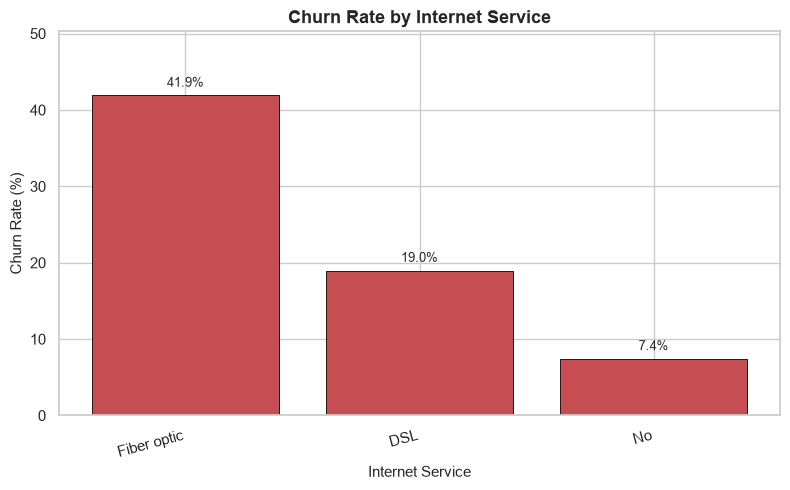

InternetService
Fiber optic    41.892765
DSL            18.959108
No              7.404980
Name: Churn, dtype: float64

In [56]:
rate_by_internet = compute_churn_rate(df, "InternetService")
plot_churn_rate_bar(rate_by_internet, "Churn Rate by Internet Service", "Internet Service")
rate_by_internet

**Interpretation.** Churn rate differs noticeably by internet service type (see values above); customers without internet service show the lowest churn, while one of the internet service tiers shows the highest. **So what does this mean for the business?** This may reflect service quality, pricing, or competitive intensity differences between service tiers, and is worth retaining as a feature and investigating operationally alongside the model.

### Churn Rate by Tenure Group

**Business question:** Is churn concentrated in a particular stage of the customer lifecycle?

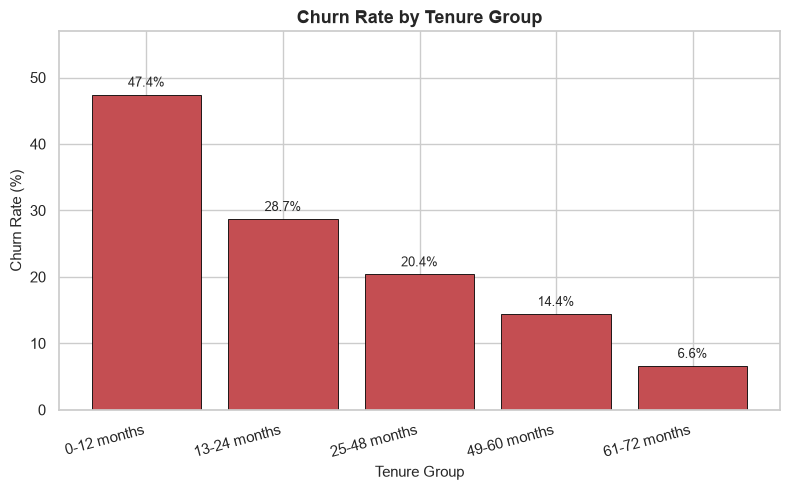

TenureGroup
0-12 months     47.438243
13-24 months    28.710938
25-48 months    20.388959
49-60 months    14.423077
61-72 months     6.609808
Name: Churn, dtype: float64

In [57]:
tenure_bins = [-1, 12, 24, 48, 60, 72]
tenure_labels = ["0-12 months", "13-24 months", "25-48 months", "49-60 months", "61-72 months"]
df_tenure_groups = df.copy()
df_tenure_groups["TenureGroup"] = pd.cut(df_tenure_groups["tenure"], bins=tenure_bins, labels=tenure_labels)

rate_by_tenure_group = compute_churn_rate(df_tenure_groups, "TenureGroup").reindex(tenure_labels)
plot_churn_rate_bar(rate_by_tenure_group, "Churn Rate by Tenure Group", "Tenure Group")
rate_by_tenure_group

**Interpretation.** Churn risk is not constant across the customer lifecycle (see values above) — newer customers churn at a noticeably higher rate than long-tenured customers, and the rate declines as tenure increases. **So what does this mean for the business?** Early-tenure customers represent the highest-risk, and likely highest-value-to-target, segment for proactive retention effort, since they have not yet built up the loyalty/switching-cost effects visible in the long-tenure group.

### Churn Rate by Senior Citizen Status

**Business question:** Does customer age bracket (senior citizen flag) relate to churn?

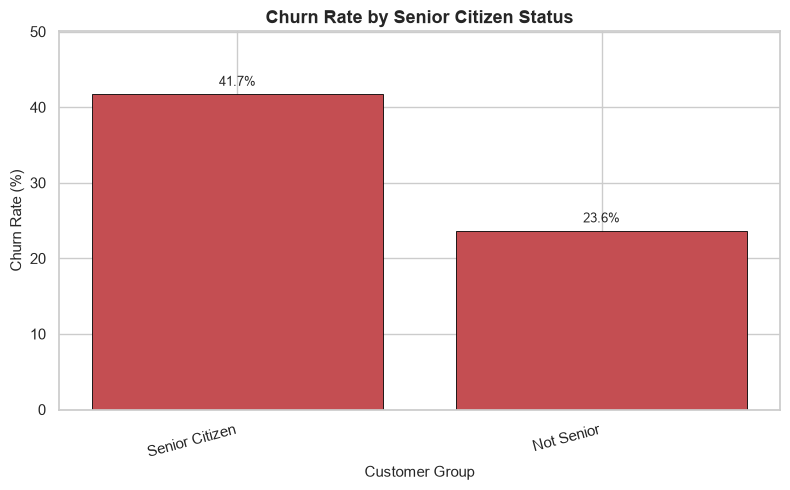

SeniorCitizen
Senior Citizen    41.681261
Not Senior        23.606168
Name: Churn, dtype: float64

In [58]:
rate_by_senior = compute_churn_rate(df, "SeniorCitizen")
rate_by_senior.index = rate_by_senior.index.map({0: "Not Senior", 1: "Senior Citizen"})
plot_churn_rate_bar(rate_by_senior, "Churn Rate by Senior Citizen Status", "Customer Group")
rate_by_senior

**Interpretation.** Senior citizens show a different churn rate than non-senior customers (see values above). **So what does this mean for the business?** If senior citizens churn more, retention messaging and support channels for this segment may warrant specific attention (e.g. simplified plans, additional support).

### Monthly Charges by Churn Status

**Business question:** Do customers who churn tend to pay more or less per month than those who stay?

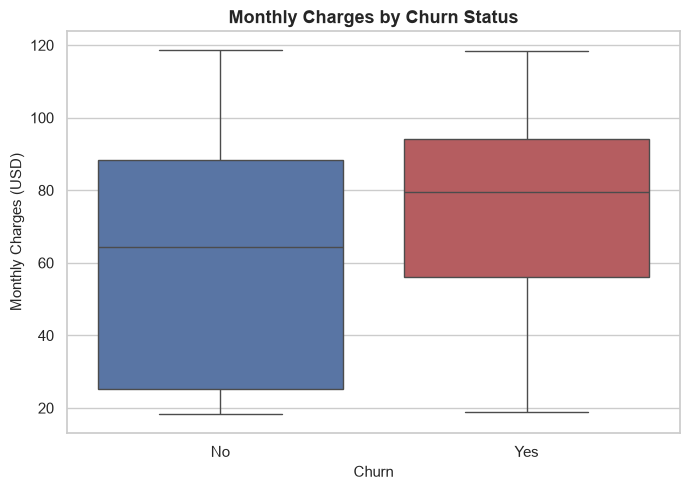

,mean,median,std
Churn,,,
No,61.3,64.4,31.1
Yes,74.4,79.6,24.7


In [59]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", hue="Churn",
            palette=CHURN_PALETTE, legend=False, ax=ax)
ax.set_title("Monthly Charges by Churn Status")
ax.set_xlabel("Churn")
ax.set_ylabel("Monthly Charges (USD)")
plt.tight_layout()
plt.show()

df.groupby("Churn")["MonthlyCharges"].agg(["mean", "median", "std"]).round(1)

**Interpretation.** The summary statistics above show whether churned customers are billed differently from retained customers on average. **So what does this mean for the business?** If churned customers pay more on average, this may indicate price sensitivity at higher billing tiers, which could inform how retention offers (e.g. discounts) are targeted.

<a id="key-findings"></a>
## 13.  Key Exploratory Findings

The summary below is generated directly from the computed statistics above — no figures are hand-typed. Directional claims (higher/lower, more/less) are stated only where the corresponding computation confirms them.

In [60]:
from IPython.display import Markdown, display

overall_churn_rate = (df["Churn"] == "Yes").mean() * 100

highest_contract = rate_by_contract.index[0]
lowest_contract = rate_by_contract.index[-1]

highest_payment = rate_by_payment.index[0]
lowest_payment = rate_by_payment.index[-1]

highest_internet = rate_by_internet.index[0]

highest_tenure_group = rate_by_tenure_group.idxmax()
lowest_tenure_group = rate_by_tenure_group.idxmin()

tenure_by_churn = df.groupby("Churn")["tenure"].mean()
charges_by_churn = df.groupby("Churn")["MonthlyCharges"].mean()

senior_gap = rate_by_senior.max() - rate_by_senior.min()

findings = f'''
- **Overall churn rate:** {overall_churn_rate:.1f}% of customers in this dataset have churned, confirming a minority-class (imbalanced) target.
- **Contract type:** churn rate is highest for **{highest_contract}** contracts ({rate_by_contract.iloc[0]:.1f}%) and lowest for **{lowest_contract}** contracts ({rate_by_contract.iloc[-1]:.1f}%).
- **Payment method:** churn rate is highest among customers paying via **{highest_payment}** ({rate_by_payment.iloc[0]:.1f}%) and lowest for **{lowest_payment}** ({rate_by_payment.iloc[-1]:.1f}%).
- **Internet service:** churn rate is highest for customers with **{highest_internet}** internet service ({rate_by_internet.iloc[0]:.1f}%).
- **Tenure:** churn is concentrated in the **{highest_tenure_group}** tenure group ({rate_by_tenure_group.max():.1f}%) and lowest in the **{lowest_tenure_group}** group ({rate_by_tenure_group.min():.1f}%). On average, churned customers have a mean tenure of {tenure_by_churn['Yes']:.1f} months versus {tenure_by_churn['No']:.1f} months for retained customers.
- **Monthly charges:** churned customers pay {('more' if charges_by_churn['Yes'] > charges_by_churn['No'] else 'less')} per month on average (${charges_by_churn['Yes']:.2f}) than retained customers (${charges_by_churn['No']:.2f}).
- **Senior citizen status:** churn rate differs by {senior_gap:.1f} percentage points between senior and non-senior customers.
'''

display(Markdown(findings))


- **Overall churn rate:** 26.5% of customers in this dataset have churned, confirming a minority-class (imbalanced) target.
- **Contract type:** churn rate is highest for **Month-to-month** contracts (42.7%) and lowest for **Two year** contracts (2.8%).
- **Payment method:** churn rate is highest among customers paying via **Electronic check** (45.3%) and lowest for **Credit card (automatic)** (15.2%).
- **Internet service:** churn rate is highest for customers with **Fiber optic** internet service (41.9%).
- **Tenure:** churn is concentrated in the **0-12 months** tenure group (47.4%) and lowest in the **61-72 months** group (6.6%). On average, churned customers have a mean tenure of 18.0 months versus 37.6 months for retained customers.
- **Monthly charges:** churned customers pay more per month on average ($74.44) than retained customers ($61.27).
- **Senior citizen status:** churn rate differs by 18.1 percentage points between senior and non-senior customers.


**Note on interpretation.** All of the directional patterns above (which group is higher or lower) are read directly from the computed output — no direction was assumed in advance. These patterns describe *observed association* within this historical dataset snapshot, not proven causal drivers of churn; they are intended to guide feature selection and business intuition for Week 2, not to be treated as final conclusions on their own.

<a id="preprocessing-strategy"></a>
## 14. Preprocessing Strategy

Building on the data quality findings above, the proposed preprocessing plan for Week 2 modelling is:

**Identifier handling.** Drop `customerID` from the model feature set entirely — it is a unique per-row identifier (Section 8.5 / Section 12) with no generalisable predictive signal.

**Target encoding.** Map `Churn` from text to a binary numeric label: `No → 0`, `Yes → 1`. This is required by scikit-learn estimators, which expect a numeric target for classification.

**Numeric variables (`tenure`, `MonthlyCharges`, `TotalCharges`).**
- Impute the 11 missing `TotalCharges` values identified in Section 10 (proposed: impute as 0, consistent with zero completed billing cycles at `tenure = 0`).
- Scale numeric features (e.g. with `StandardScaler`) for scale-sensitive algorithms such as Logistic Regression; scaling is less critical for tree-based models but does no harm.

**Categorical variables.** Apply one-hot encoding (`pd.get_dummies` or `OneHotEncoder`) to multi-class categorical columns (e.g. `Contract`, `PaymentMethod`, `InternetService`), and binary 0/1 mapping to two-level Yes/No columns.

**Train/test split.** Use a **stratified** train/test split (`train_test_split(..., stratify=y, random_state=RANDOM_STATE)`) so that the minority churn class is represented in the same proportion in both the training and test sets — important given the class imbalance quantified in Section 13.

**Leakage prevention.** All preprocessing transformations (imputers, scalers, encoders) must be **fit only on the training partition**, then applied (`.transform()`) to the test partition. Fitting on the full dataset before splitting would leak information about the test set into training, producing an overly optimistic and unreliable performance estimate.

**Reproducibility.** Use a fixed `random_state` (`RANDOM_STATE = 42`, defined once in Section 6) for every stochastic operation — the train/test split, and any model with a random component (e.g. Random Forest) — so that results are reproducible across runs.

**Recommended implementation.** In the modelling phase, these steps should be assembled into a single scikit-learn `Pipeline` combined with a `ColumnTransformer` (applying the numeric steps to numeric columns and the categorical steps to categorical columns). This keeps preprocessing and modelling as one fittable object, which further reduces the risk of leakage and makes the workflow easy to re-run and deploy.

<a id="model-planning"></a>
## 15. Model Planning

| Model | Type | Strengths | Weaknesses | Why Suitable |
|---|---|---|---|---|
| **Logistic Regression** | Linear, probabilistic classifier | Highly interpretable coefficients; fast to train; well-calibrated probabilities; strong baseline | Assumes a linear decision boundary in log-odds space; limited capacity for complex feature interactions | Establishes an interpretable, business-explainable baseline against which more complex models are compared |
| **Decision Tree** | Non-linear, rule-based classifier | Captures non-linear splits and interactions; easy to visualise and explain | Prone to overfitting without depth/leaf constraints; sensitive to small data changes | Useful for surfacing human-readable decision rules the retention team can sanity-check |
| **Random Forest** | Ensemble of decision trees | Reduces overfitting vs. a single tree; strong general-purpose accuracy; provides feature importance | Less interpretable than a single tree or logistic regression; heavier compute and slower inference | Robust, typically high-performing default choice for tabular churn data |
| **Gradient Boosting** (e.g. XGBoost / LightGBM / CatBoost as future alternatives) | Sequential ensemble of weak learners | Often achieves the strongest raw predictive performance on tabular data; handles feature interactions well | Most hyperparameter-sensitive; least interpretable without additional tooling (e.g. SHAP) | Worth benchmarking once simpler baselines are established, if the added complexity is justified by a meaningful performance gain |

**Recommended approach:** start with **Logistic Regression as an interpretable baseline**, then compare against **tree-based ensemble models** (Random Forest, and optionally Gradient Boosting) to see whether the added model complexity yields a meaningful improvement over the baseline.

Final model selection should be driven by **validation results on held-out data and business priorities** (e.g. recall for the churn class) — not by assuming in advance that a more complex model will necessarily perform better.

<a id="evaluation-strategy"></a>
## 16. Evaluation Strategy

The proposed evaluation approach for Week 2 modelling:

1. **Stratified train/test split** — preserves the churn/non-churn ratio in both partitions (Section 16).
2. **Cross-validation** (e.g. stratified k-fold) on the training partition — provides a more robust estimate of model performance than a single train/validation split, and supports hyperparameter selection without touching the final test set.
3. **Confusion matrix** — reported on the held-out test set as the primary diagnostic, since it makes every prediction outcome explicit.
4. **Precision, Recall, F1-score** — computed for the churn (positive) class specifically, not only "macro" or "weighted" averages, since the minority class is the one that matters operationally.
5. **ROC-AUC** — reported as a threshold-independent summary of ranking quality.
6. **Accuracy** — reported as a supporting, secondary metric only, given the class imbalance discussed in Section 11.

**Business meaning of the confusion matrix outcomes:**

- **False Positive** — the model predicts a customer will churn, but they do not. Cost: an unnecessary retention offer or contact is made to a customer who was not actually at risk.
- **False Negative** — the model predicts a customer will stay, but they actually churn. Cost: a genuinely at-risk customer receives no intervention and is lost, along with their future revenue.

**Why false negatives matter more here.** In this use case, a missed churner (false negative) represents a customer the business had a chance to save but did not act on, while a false positive typically only costs the (usually smaller) price of an unneeded retention gesture. This asymmetry is why **Recall** for the churn class was highlighted in Section 11 as a priority metric alongside precision and F1 — final threshold selection should reflect this business trade-off rather than defaulting to the standard 0.5 probability cutoff.

<a id="ml-proposal"></a>
## 17. Machine Learning Proposal

### Problem Statement
ABC Communications Ltd currently has no systematic way to identify which existing customers are at elevated risk of churning. Retention efforts, if any, cannot be reliably targeted without a risk signal derived from customer data.

### Objective
Develop a supervised machine learning model that estimates each existing customer's probability of churning, enabling the retention team to prioritise proactive outreach toward the highest-risk, highest-value customers.

### Target Variable
`Churn` (binary: `Yes` / `No`, encoded as 1 / 0 for modelling).

### Candidate Features
Account and contract attributes (`tenure`, `Contract`, `PaymentMethod`, `PaperlessBilling`, `MonthlyCharges`, `TotalCharges`), demographics (`SeniorCitizen`, `Partner`, `Dependents`, `gender`), and subscribed services (`PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`). `customerID` is explicitly excluded as a non-predictive identifier.

### Problem Type
Supervised **binary classification**.

### Data Preparation
Convert `TotalCharges` to numeric and impute the resulting missing values; encode `Churn` as 0/1; one-hot encode multi-class categorical features; scale numeric features; perform a stratified train/test split before fitting any transformation, to prevent data leakage (Section 16).

### Candidate Algorithms
Logistic Regression (interpretable baseline), Decision Tree, and Random Forest, with Gradient Boosting (or XGBoost/LightGBM/CatBoost) as an optional future comparison once baselines are established (Section 17).

### Evaluation Metrics
Precision, Recall, and F1-score for the churn class; ROC-AUC; confusion matrix; accuracy as a supporting metric only, given class imbalance (Section 18).

### Validation Strategy
Stratified train/test split combined with stratified k-fold cross-validation on the training data for model selection and hyperparameter tuning; final performance reported once, on the untouched held-out test set.

### Expected Business Use
Risk scores generated by the model would be consumed by the customer retention/success team to prioritise outreach, and could be recalculated periodically (e.g. monthly) as customer data updates.

### Risks and Limitations
See the dedicated section below.

### Next Steps
Proceed to Week 2: implement the preprocessing pipeline, train and validate the candidate baseline models on a stratified split, and compare their performance using the metrics defined above before recommending a model for further development.

<a id="risks-limitations"></a>
## 18. Risks and Limitations

- **Historical data may not represent future customer behaviour.** Market conditions, competitor offers, and pricing can shift, changing churn drivers over time.
- **Correlation does not establish causation.** The associations identified in Section 13 describe statistical patterns, not proven causal mechanisms — acting on them as if they were causal (e.g. assuming a price cut *causes* reduced churn) requires further validation, ideally through controlled experimentation.
- **Customer behaviour can change** independently of any variable captured in this dataset (e.g. life events, competitor promotions).
- **Class imbalance** (Section 13) can distort naive accuracy-based evaluation and requires the metric choices proposed in Section 18.
- **Identifier variables must not be treated as predictors** — `customerID` carries no generalisable signal and must be excluded (Sections 11–12, 16).
- **Model predictions should support, not replace, business judgement** — a churn-risk score is a decision-support input for the retention team, not an automatic action trigger.
- **Retention interventions may themselves change future customer behaviour**, meaning a model trained on historical (non-intervened) data may need periodic retraining once interventions based on its own predictions begin influencing outcomes.
- **Data quality issues can affect model reliability** — the `TotalCharges` handling identified in Section 10 is a concrete example of an issue that must be resolved carefully rather than ignored.

<a id="conclusion"></a>
## 19. Final Conclusion

This notebook examined the business problem of customer churn at ABC Communications Ltd and established that it is well-suited to a supervised, binary classification approach using the Telco Customer Churn dataset. Dataset inspection confirmed a clean, one-row-per-customer structure with no full-row duplicates, and identified a single concrete data-quality issue — `TotalCharges` stored as text with 11 blank entries corresponding to zero-tenure customers — that must be addressed through explicit numeric conversion and imputation rather than assumption.

The problem was formally framed around the `Churn` target, with `customerID` explicitly excluded as a non-predictive identifier and the remaining account, demographic, and service attributes retained as candidate features pending empirical validation. Exploratory analysis quantified a minority-class churn base rate and surfaced clear, data-backed associations between churn and contract type, payment method, internet service, and tenure — findings that both justify the chosen features and motivate the emphasis on recall-sensitive evaluation metrics over accuracy alone.

Preprocessing needs (encoding, scaling, missing-value imputation, leakage-safe train/test splitting) have been identified and explained, and a concrete modelling plan has been proposed: an interpretable Logistic Regression baseline compared against Random Forest and, optionally, Gradient Boosting, evaluated primarily on precision, recall, F1, and ROC-AUC for the churn class.

**No model has been trained or evaluated in this notebook.** Week 2 should implement the preprocessing pipeline defined in Section 16, train the candidate models defined in Section 17 on a stratified split, and evaluate them using the metrics defined in Section 18 before recommending a model for further development.

<a id="references"></a>
## 20. References

- AnalystLab Africa Machine Learning Internship Programme, Week 1 Assignment Brief: Machine Learning Problem Framing & Data Understanding.
- Telco Customer Churn Dataset (IBM Sample Data), via Kaggle: [https://www.kaggle.com/datasets/blastchar/telco-customer-churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)
- scikit-learn documentation — supervised learning and model evaluation: [https://scikit-learn.org/stable/](https://scikit-learn.org/stable/)
- pandas documentation: [https://pandas.pydata.org/docs/](https://pandas.pydata.org/docs/)
- seaborn documentation: [https://seaborn.pydata.org/](https://seaborn.pydata.org/)

<a id="submission-checklist"></a>
## 21. Submission Checklist

This notebook consolidates the Week 1 **analytical and reporting deliverables** — business understanding, dataset inspection, ML problem framing, exploratory analysis, and the ML proposal — into a single self-contained Jupyter Notebook. External platform submissions remain the intern's own responsibility to complete and confirm.

- [x] Business Understanding Report — Section: Business Understanding
- [x] Dataset Inspection Report — Sections: Dataset Overview, Dataset Inspection, Data Quality Assessment
- [x] Jupyter Notebook — this document
- [x] Machine Learning Proposal — Section: Machine Learning Proposal
- [ ] GitHub Repository — push this notebook and the dataset (or dataset-access instructions) to the intern's repository
- [ ] LinkedIn Post — share a summary of the Week 1 project, mentioning AnalystLab Africa and including the hashtag `#AnalystLabAfrica`
- [ ] X Post — share a summary of the Week 1 project, tagging `@analystlabafric` and including the hashtag `#AnalystLabAfrica`
- [ ] LinkedIn Profile Updated — reflect this project/internship on the intern's profile
- [ ] Google Drive Link Submitted — upload the final notebook and share the link per programme instructions